# Problem Statement
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by 
"National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us 
to perform this prediction.

Constraints on data collection
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage

# Dataset:
https://www.kaggle.com/kumargh/pimaindiansdiabetescsv

# 1. Import Libraries and load dataset

In [53]:
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
#from sklearn.feature_extraction.text import CountVectorizer  #DT does not take strings as input for the model fit step....
from IPython.display import Image  
#import pydotplus as pydot
from sklearn import tree
from os import system

It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number 
of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma 
separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What 
information is available about the data.

# 2. Print 10 samples from the dataset

In [54]:
diabetes = pd.read_csv("pima-indians-diabetes.csv")
diabetes.head(10) #several missing values!

,Preg,Plas,Pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# 3. Print the datatypes of each column and the shape of the dataset

In [55]:
diabetes.shape


(768, 9)

There are '0's in the data. Are they really valid '0's or they are missing values? Plasma, BP, skin thickness etc. these values 
cannot be 0. look at column by column logically to understand this.

# 4. Replace all the 0s in the column with the median of the same column value accordingly.

In [56]:
diabetes['Plas'] = diabetes['Plas'].map( lambda x : diabetes.Plas.mean() if x == 0 else x)
diabetes['skin'] = diabetes['skin'].map( lambda x : diabetes.skin.mean() if x == 0 else x)
diabetes['mass'] = diabetes['mass'].map( lambda x : diabetes.mass.mean() if x == 0 else x)





# 5. Print the descriptive statistics of each & every column using describe() function

In [57]:
diabetes.describe()

,Preg,Plas,Pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.681605,69.105469,26.606479,79.799479,32.450805,0.471876,33.240885,0.348958
std,3.369578,30.436016,19.355807,9.631241,115.244002,6.875374,0.331329,11.760232,0.476951
min,0.000000,44.000000,0.000000,7.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,62.000000,20.536458,0.000000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# 6. See the distribution of 'Class' variable and plot it using appropriate graph

class
0    500
1    268
dtype: int64


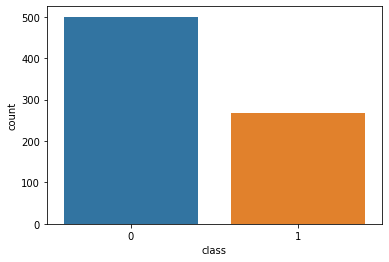

In [58]:
print(diabetes.groupby('class').size())
import seaborn as sns

sns.countplot(diabetes['class'],label="Count")

# 7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables

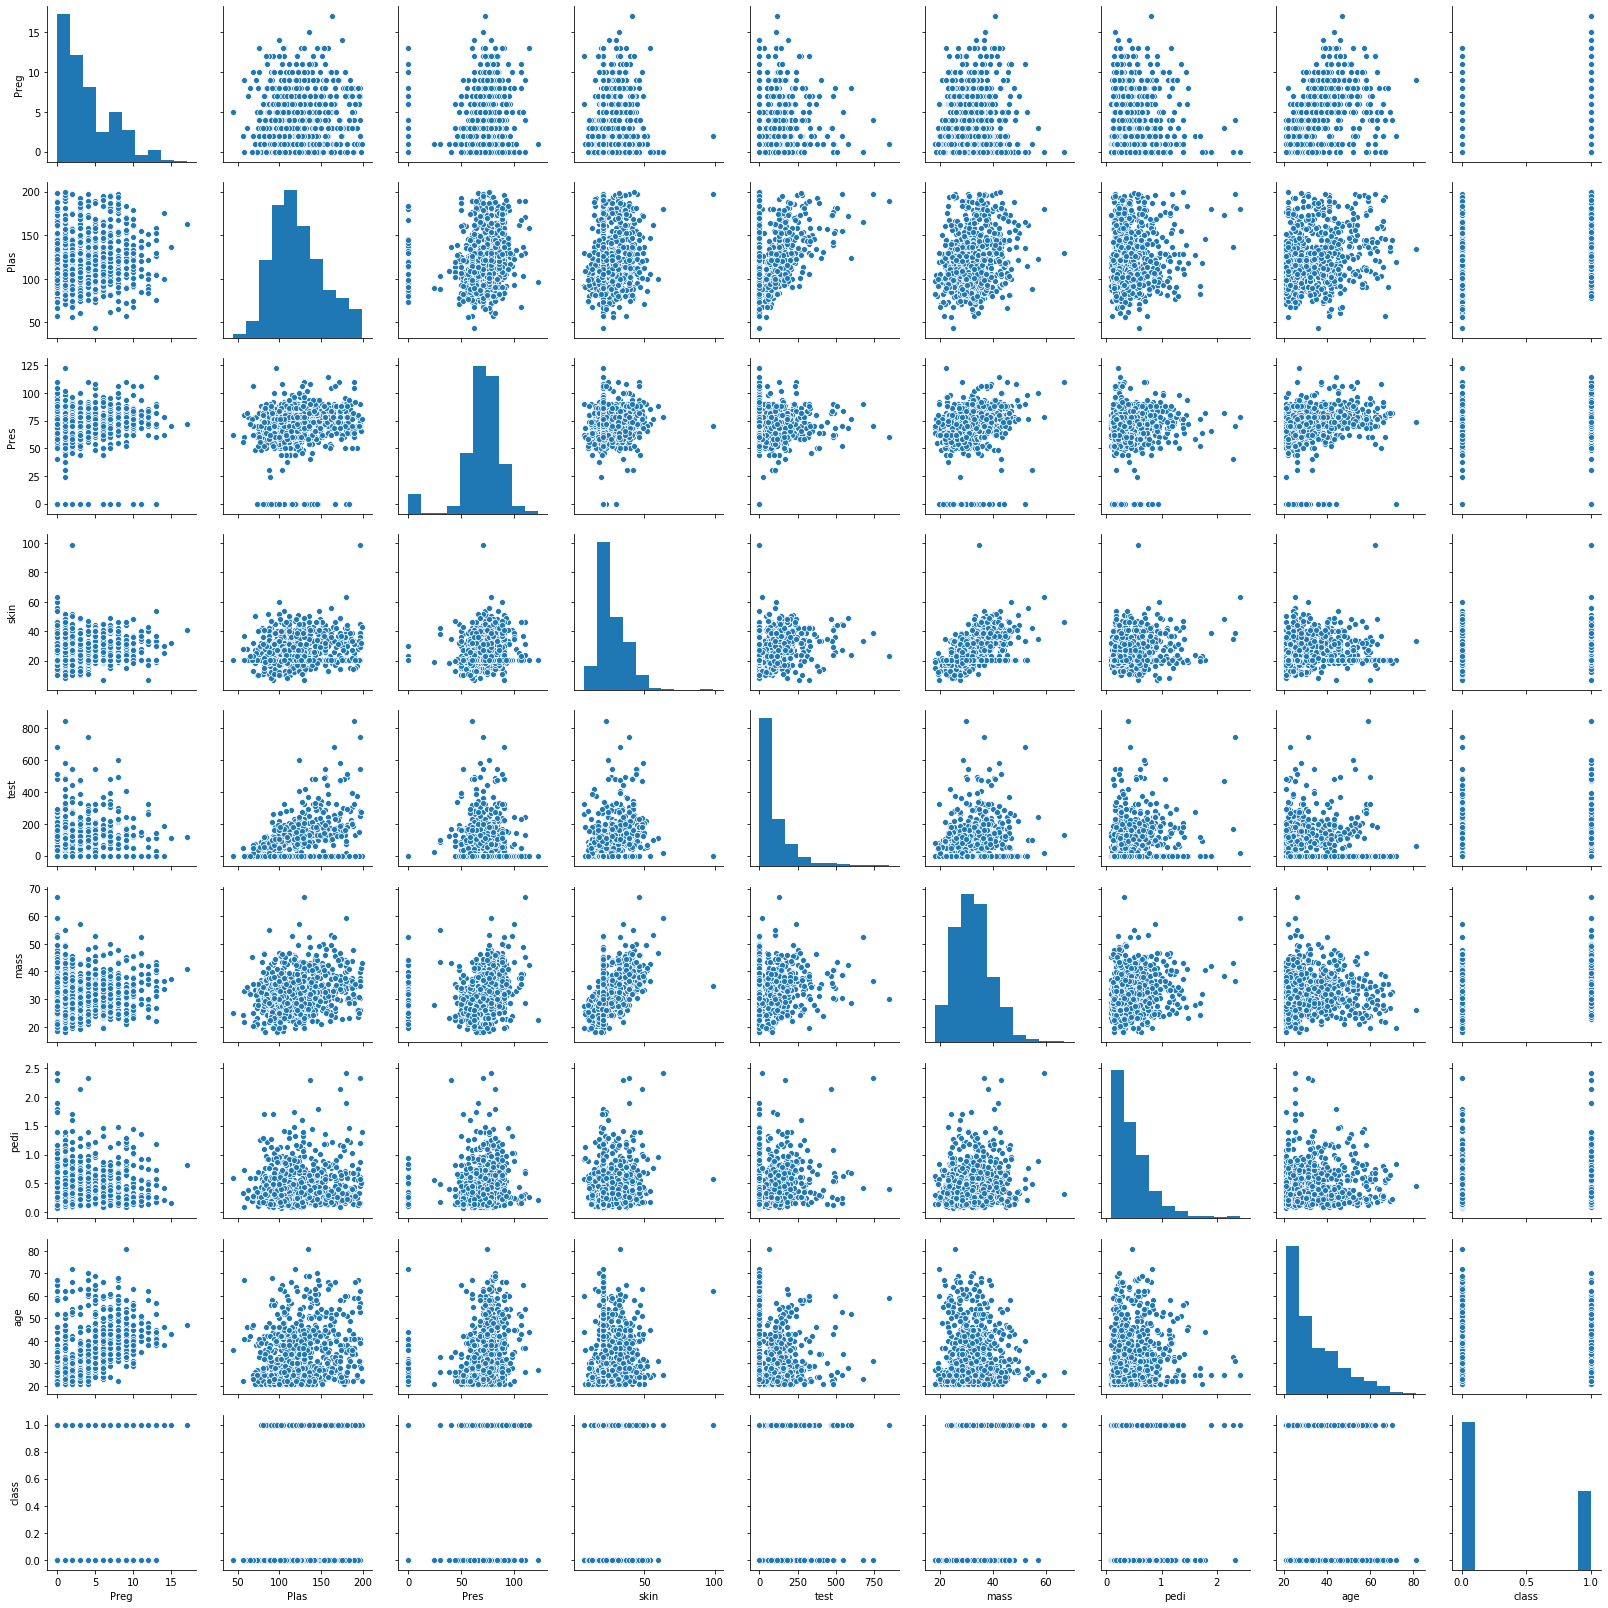

In [59]:
import seaborn as sns
sns.pairplot(diabetes)


Check for correlation between variables whose values are >0.8

In [60]:
diabetes.corr()

,Preg,Plas,Pres,skin,test,mass,pedi,age,class
Preg,1.000000,0.127964,0.141282,0.013376,-0.073535,0.021546,-0.033523,0.544341,0.221898
Plas,0.127964,1.000000,0.158279,0.160766,0.331190,0.231478,0.137106,0.266600,0.492908
Pres,0.141282,0.158279,1.000000,0.180890,0.088933,0.184252,0.041265,0.239528,0.065068
skin,0.013376,0.160766,0.180890,1.000000,0.286469,0.535703,0.154961,0.026423,0.175026
test,-0.073535,0.331190,0.088933,0.286469,1.000000,0.185365,0.185071,-0.042163,0.130548
mass,0.021546,0.231478,0.184252,0.535703,0.185365,1.000000,0.153508,0.025748,0.312254
pedi,-0.033523,0.137106,0.041265,0.154961,0.185071,0.153508,1.000000,0.033561,0.173844
age,0.544341,0.266600,0.239528,0.026423,-0.042163,0.025748,0.033561,1.000000,0.238356
class,0.221898,0.492908,0.065068,0.175026,0.130548,0.312254,0.173844,0.238356,1.000000


# 8. Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).

In [62]:
diabetes.head()
X = diabetes.drop("class" , axis=1)
y = diabetes.pop("class")
diabetes.head()



,Preg,Plas,Pres,skin,test,mass,pedi,age
0,6,148.0,72,35.000000,0,33.6,0.627,50
1,1,85.0,66,29.000000,0,26.6,0.351,31
2,8,183.0,64,20.536458,0,23.3,0.672,32
3,1,89.0,66,23.000000,94,28.1,0.167,21
4,0,137.0,40,35.000000,168,43.1,2.288,33


In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=1)

# 9. Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.

In [108]:
dTree = DecisionTreeClassifier(criterion = 'entropy', random_state=1)
dTree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
                       max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort=False,
                       random_state=1, splitter='best')

# 10. Print the accuracy of the model & print the confusion matrix

In [109]:
print(dTree.score(X_train, y_train))
print(dTree.score(X_test, y_test))

1.0
0.7229437229437229


In [110]:
dTreeR = DecisionTreeClassifier(criterion = 'entropy', max_depth =6, random_state=1)
dTreeR.fit(X_train, y_train)
print(dTreeR.score(X_train, y_train))
print(dTreeR.score(X_test, y_test))

0.8566108007448789
0.7835497835497836


In [74]:
# importance of features in the tree building ( The importance of a feature is computed as the 
#(normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print (pd.DataFrame(dTreeR.feature_importances_, columns = ["Imp"], index = X_train.columns))

           Imp
Preg  0.045382
Plas  0.335882
Pres  0.085685
skin  0.040464
test  0.024526
mass  0.242951
pedi  0.071128
age   0.153982


0.7835497835497836


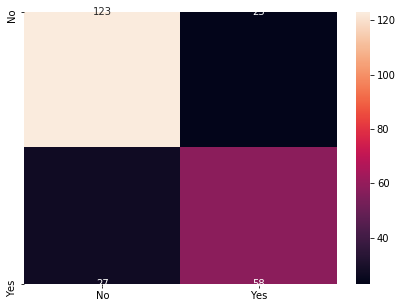

In [78]:
print(dTreeR.score(X_test , y_test))
y_predict = dTreeR.predict(X_test)

cm=metrics.confusion_matrix(y_test, y_predict, labels=[0, 1])

df_cm = pd.DataFrame(cm, index = [i for i in ["No","Yes"]],
                  columns = [i for i in ["No","Yes"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True ,fmt='g')

# 11. Apply the Random forest model and print the accuracy of Random forest Model

In [84]:
from sklearn.ensemble import RandomForestClassifier
rfcl = RandomForestClassifier(n_estimators = 50, random_state=1,max_features=4)
rfcl = rfcl.fit(X_train, y_train)

print(rfcl.score(X_train, y_train))
print(rfcl.score(X_test, y_test))

0.9981378026070763
0.7965367965367965


0.7965367965367965


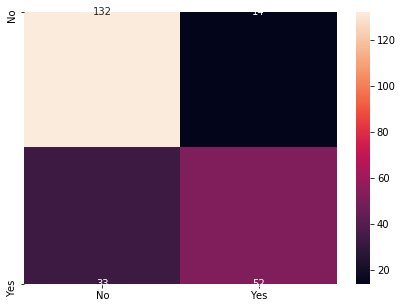

In [85]:
y_predict = rfcl.predict(X_test)
print(rfcl.score(X_test, y_test))
cm=metrics.confusion_matrix(y_test, y_predict,labels=[0, 1])

df_cm = pd.DataFrame(cm, index = [i for i in ["No","Yes"]],
                  columns = [i for i in ["No","Yes"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True ,fmt='g')

# 12. Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [117]:
from sklearn.ensemble import AdaBoostClassifier
abcl = AdaBoostClassifier(n_estimators=60, random_state=1)
#abcl = AdaBoostClassifier( n_estimators=50,random_state=1)
abcl = abcl.fit(X_train, y_train)

In [118]:
print(abcl.score(X_train, y_train))
print(abcl.score(X_test, y_test))

0.851024208566108
0.8008658008658008


0.8008658008658008


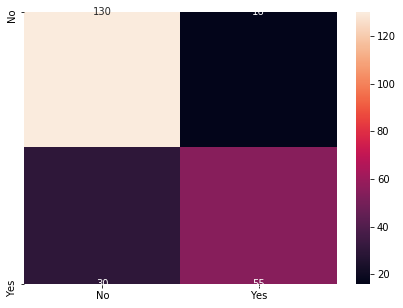

In [119]:
y_predict = abcl.predict(X_test)
print(abcl.score(X_test , y_test))

cm=metrics.confusion_matrix(y_test, y_predict,labels=[0, 1])

df_cm = pd.DataFrame(cm, index = [i for i in ["No","Yes"]],
                  columns = [i for i in ["No","Yes"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True ,fmt='g')

# 13. Apply Bagging Classifier Algorithm and print the accuracy.

In [97]:
from sklearn.ensemble import BaggingClassifier

bgcl = BaggingClassifier(base_estimator=dTree, n_estimators=50,random_state=1)
#bgcl = BaggingClassifier(n_estimators=50,random_state=1)

bgcl = bgcl.fit(X_train, y_train)

In [101]:
print(bgcl.score(X_train, y_train))
print(bgcl.score(X_test, y_test))

0.9981378026070763
0.7835497835497836


0.7835497835497836


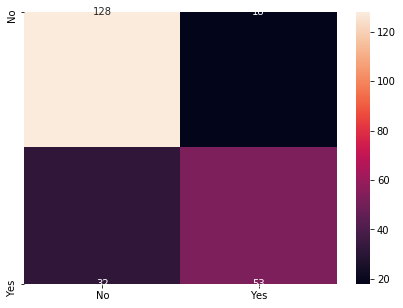

In [102]:
y_predict = bgcl.predict(X_test)

print(bgcl.score(X_test , y_test))

cm=metrics.confusion_matrix(y_test, y_predict,labels=[0, 1])

df_cm = pd.DataFrame(cm, index = [i for i in ["No","Yes"]],
                  columns = [i for i in ["No","Yes"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True ,fmt='g')

# 14. Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

In [100]:
from sklearn.ensemble import GradientBoostingClassifier
gbcl = GradientBoostingClassifier(n_estimators = 50,random_state=1)
gbcl = gbcl.fit(X_train, y_train)

In [103]:
print(bgcl.score(X_train, y_train))
print(bgcl.score(X_test, y_test))

0.9981378026070763
0.7835497835497836


0.8008658008658008


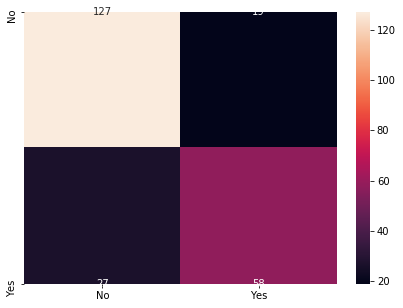

In [104]:
y_predict = gbcl.predict(X_test)
print(gbcl.score(X_test, y_test))
cm=metrics.confusion_matrix(y_test, y_predict,labels=[0, 1])

df_cm = pd.DataFrame(cm, index = [i for i in ["No","Yes"]],
                  columns = [i for i in ["No","Yes"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True ,fmt='g')